In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
from itertools import product

from sklearn.cluster import KMeans
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/Colab Notebooks/dataset/AirlineDataset.csv'
data = pd.read_csv(file_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Feature selection
flight_stats = ["Flight Distance", "Departure Delay in Minutes"]
passenger_experience = ["Inflight wifi service", "Inflight entertainment", "Online boarding", "Ease of Online booking"]
service_comfort = ["Food and drink", "Departure/Arrival time convenient", "Seat comfort"]

# Combine all selected features into one list
selected_features = flight_stats + passenger_experience + service_comfort

# Standardizing the features for better clustering performance
df_numeric = data[selected_features]

# Drop rows with missing values
X = df_numeric.dropna()

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

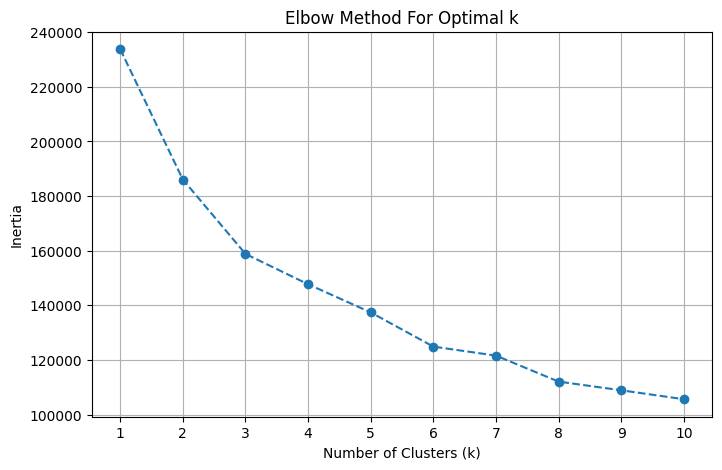

In [ ]:
# Determine the optimal number of clusters using the Elbow Method
inertia = []
k_values = range(1, 11)  # Test k from 1 to 10

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid()
plt.show()

In [ ]:
# K-Means Clustering
optimal_k = 3  # Predefined number of clusters
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
data['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
data.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,...,2,2,2,2,4,2,4,0,20.0,satisfied


In [ ]:
data.isnull().sum()


,0
Unnamed: 0,0
id,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0


In [ ]:
data=data.fillna(0)
data

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,...,2,2,2,2,4,2,4,0,20.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25971,25971,78463,Male,disloyal Customer,34,Business travel,Business,526,3,3,...,4,3,2,4,4,5,4,0,0.0,neutral or dissatisfied
25972,25972,71167,Male,Loyal Customer,23,Business travel,Business,646,4,4,...,4,4,5,5,5,5,4,0,0.0,satisfied
25973,25973,37675,Female,Loyal Customer,17,Personal Travel,Eco,828,2,5,...,2,4,3,4,5,4,2,0,0.0,neutral or dissatisfied
25974,25974,90086,Male,Loyal Customer,14,Business travel,Business,1127,3,3,...,4,3,2,5,4,5,4,0,0.0,satisfied


In [ ]:
data.isnull().sum()


,0
Unnamed: 0,0
id,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0


In [ ]:
from sklearn.model_selection import train_test_split
x = data.loc[:,:'Departure Delay in Minutes']
y = data['satisfaction']
# spilt the dataset
x_train , x_test , y_train , y_test = train_test_split(x,y, stratify = y , test_size = 0.3, random_state = 42)

In [ ]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

# Create synthetic data with three clusters
X, y = make_blobs(n_samples=300, centers=3, random_state=42, cluster_std=0.70)

# Apply different clustering algorithms
algorithms = [
    ("KMeans", KMeans(n_clusters=3, random_state=42)),
    ("Agglomerative", AgglomerativeClustering(n_clusters=3)),
    ("DBSCAN", DBSCAN(eps=0.5, min_samples=5))
]

# Evaluate clustering performance using silhouette score
for name, algorithm in algorithms:
    if name == "DBSCAN":
        labels = algorithm.fit_predict(X)
    else:
        algorithm.fit(X)
        labels = algorithm.labels_

    silhouette_avg = silhouette_score(X, labels)
    print(f"{name} - Silhouette Score: {silhouette_avg}")

KMeans - Silhouette Score: 0.8932417420300518
Agglomerative - Silhouette Score: 0.8932417420300518
DBSCAN - Silhouette Score: 0.7645464829896885


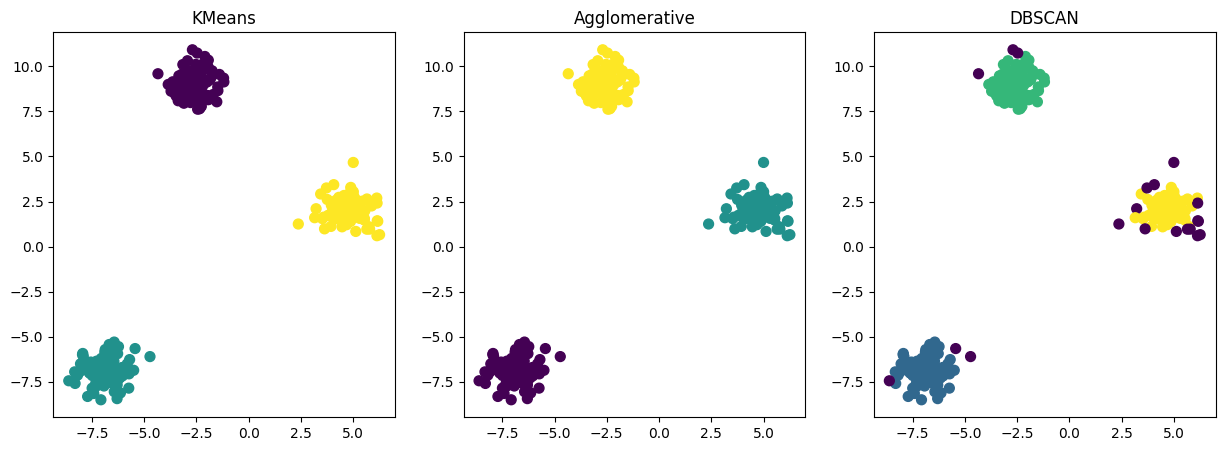

In [ ]:
fig, axes = plt.subplots(1, len(algorithms), figsize=(15, 5))

for i, (name, algorithm) in enumerate(algorithms):
    if name == "DBSCAN":
        labels = algorithm.fit_predict(X)
    else:
        algorithm.fit(X)
        labels = algorithm.labels_

    axes[i].scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis')
    axes[i].set_title(name)

plt.show()

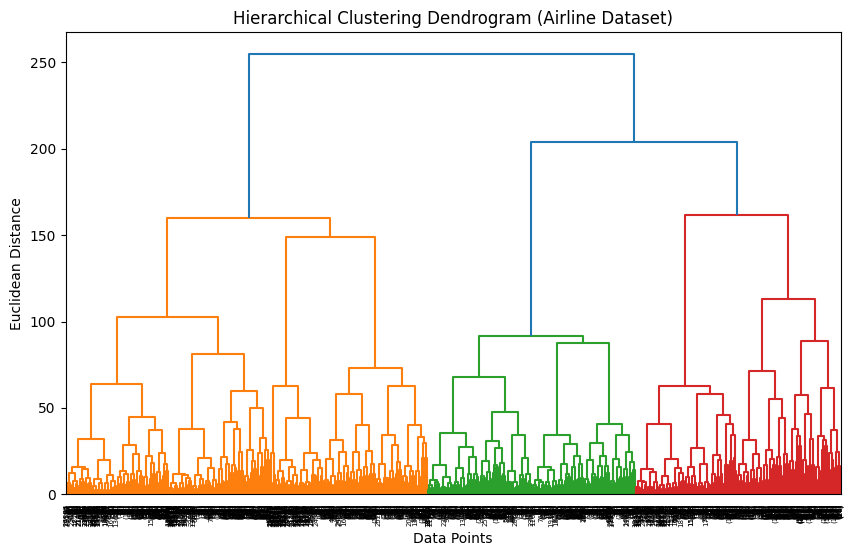

   Hierarchical_Cluster    Hierarchical_Cluster_Name
0                     2        Aggressive Early Game
1                     0  Strategic Objective Control
2                     1         Gold Advantage Focus
3                     0  Strategic Objective Control
4                     1         Gold Advantage Focus


In [ ]:
# Hierarchical Clustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# Perform hierarchical clustering using Ward's method
linked = linkage(X_scaled, method='ward')

# Plot Dendrogram
plt.figure(figsize=(10, 6))
dendrogram(linked, truncate_mode='level', p=10)
plt.title("Hierarchical Clustering Dendrogram (Airline Dataset)")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

# Determine the optimal number of clusters (e.g., 3 based on dendrogram)
optimal_clusters = 3

# Perform Agglomerative Clustering
hierarchical = AgglomerativeClustering(n_clusters=optimal_clusters, linkage='ward')
data['Hierarchical_Cluster'] = hierarchical.fit_predict(X_scaled)

# Assign Cluster Names for Hierarchical Clustering
cluster_names_hierarchical = {
    0: "Strategic Objective Control",
    1: "Gold Advantage Focus",
    2: "Aggressive Early Game"
}
data['Hierarchical_Cluster_Name'] = data['Hierarchical_Cluster'].map(cluster_names_hierarchical)

# Display the first few rows with cluster assignments
print(data[['Hierarchical_Cluster', 'Hierarchical_Cluster_Name']].head())


In [ ]:
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(X_scaled, data['Hierarchical_Cluster'])
print(f"Silhouette Score (Hierarchical Clustering): {silhouette_avg:.4f}")

Silhouette Score (Hierarchical Clustering): 0.1170


In [ ]:
# Ensure K-Means clustering is applied and the column is created
if 'KMeans_Cluster' not in data.columns:
    print("KMeans_Cluster column not found. Applying K-Means clustering...")
    # Apply K-Means clustering
    optimal_k = 3  # Predefined number of clusters
    kmeans = KMeans(n_clusters=optimal_k, random_state=42)
    data['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)
    print("KMeans_Cluster column created.")

# Check if DBSCAN clustering is applied
if 'DBSCAN_Cluster' not in data.columns:
    print("DBSCAN_Cluster column not found. Applying DBSCAN clustering...")
    # Apply DBSCAN clustering
    dbscan = DBSCAN(eps=0.5, min_samples=5)  # Adjust parameters as needed
    data['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)
    print("DBSCAN_Cluster column created.")

# Check if Hierarchical clustering is applied
if 'Hierarchical_Cluster' not in data.columns:
    print("Hierarchical_Cluster column not found. Applying Hierarchical clustering...")
    # Apply Hierarchical clustering
    hierarchical = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
    data['Hierarchical_Cluster'] = hierarchical.fit_predict(X_scaled)
    print("Hierarchical_Cluster column created.")

# Function to compute Silhouette Score
def compute_silhouette_score(X, labels):
    """
    Compute the Silhouette Score for clustering results.
    Excludes noise points (label = -1) for DBSCAN.
    Returns None if the score cannot be computed (e.g., only one cluster or all noise).
    """
    # Exclude noise points (label = -1)
    valid_labels = labels[labels != -1]
    valid_data = X[labels != -1]

    # Silhouette Score requires at least 2 clusters
    if len(set(valid_labels)) > 1:
        return silhouette_score(valid_data, valid_labels)
    else:
        return None  # Return None if the score cannot be computed

# Function to count clusters
def count_clusters(labels):
    """
    Count the number of clusters, excluding noise points (label = -1) if present.
    """
    unique_labels = set(labels)
    if -1 in unique_labels:
        return len(unique_labels) - 1  # Exclude noise points
    else:
        return len(unique_labels)

# Compute and print Silhouette Scores
print(f"Silhouette Score (K-Means): {compute_silhouette_score(X_scaled, data['KMeans_Cluster']) or 'N/A':.4f}")
print(f"Silhouette Score (DBSCAN): {compute_silhouette_score(X_scaled, data['DBSCAN_Cluster']) or 'N/A':.4f}")
print(f"Silhouette Score (Hierarchical Clustering): {compute_silhouette_score(X_scaled, data['Hierarchical_Cluster']) or 'N/A':.4f}")

# Compute and print the number of clusters
print(f"Number of Clusters (K-Means): {count_clusters(data['KMeans_Cluster'])}")
print(f"Number of Clusters (DBSCAN): {count_clusters(data['DBSCAN_Cluster'])}")
print(f"Number of Clusters (Hierarchical Clustering): {count_clusters(data['Hierarchical_Cluster'])}")


KMeans_Cluster column not found. Applying K-Means clustering...
KMeans_Cluster column created.
DBSCAN_Cluster column not found. Applying DBSCAN clustering...
DBSCAN_Cluster column created.
Silhouette Score (K-Means): 0.1934
Silhouette Score (DBSCAN): 0.2644
Silhouette Score (Hierarchical Clustering): 0.1170
Number of Clusters (K-Means): 3
Number of Clusters (DBSCAN): 572
Number of Clusters (Hierarchical Clustering): 3


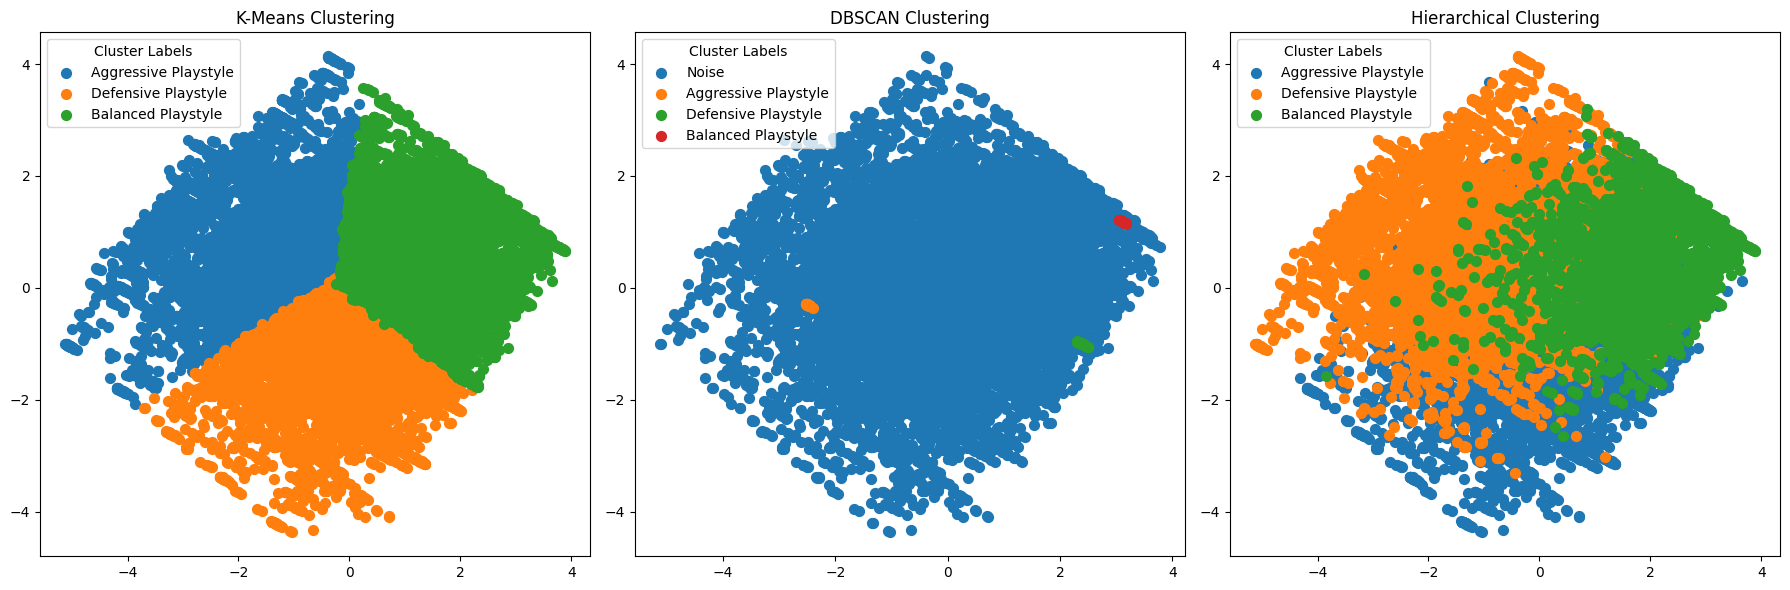

In [ ]:
# Define cluster names
cluster_names = {
    0: "Aggressive Playstyle",
    1: "Defensive Playstyle",
    2: "Balanced Playstyle",
    -1: "Noise"  # For DBSCAN noise points
}

# Function to annotate points with cluster labels
def annotate_clusters(ax, data, cluster_col, title, unique_clusters):
    for cluster in unique_clusters:
        if cluster in cluster_names:  # Only plot clusters with defined names
            cluster_points = reduced_data[data[cluster_col] == cluster]
            label = cluster_names[cluster]
            ax.scatter(cluster_points[:, 0], cluster_points[:, 1], label=label, s=50)
    ax.set_title(title)
    ax.legend(title="Cluster Labels")

# Cluster Visualization with Named Labels
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# K-Means Clustering
annotate_clusters(axes[0], data, 'KMeans_Cluster', "K-Means Clustering", np.unique(data['KMeans_Cluster']))

# DBSCAN Clustering
annotate_clusters(axes[1], data, 'DBSCAN_Cluster', "DBSCAN Clustering", np.unique(data['DBSCAN_Cluster']))

# Hierarchical Clustering
annotate_clusters(axes[2], data, 'Hierarchical_Cluster', "Hierarchical Clustering", np.unique(data['Hierarchical_Cluster']))

plt.tight_layout()
plt.show()

K-Means Contingency Table:
 satisfaction    neutral or dissatisfied  satisfied
KMeans_Cluster                                    
0                                  6886       1026
1                                  4148       3766
2                                  3539       6611
DBSCAN Contingency Table:
 satisfaction    neutral or dissatisfied  satisfied
DBSCAN_Cluster                                    
-1                                 7294       6088
 0                                   24          0
 1                                    0         46
Hierarchical Clustering Contingency Table:
 satisfaction          neutral or dissatisfied  satisfied
Hierarchical_Cluster                                    
0                                        4565       4989
1                                        8035       2433
2                                        1973       3981


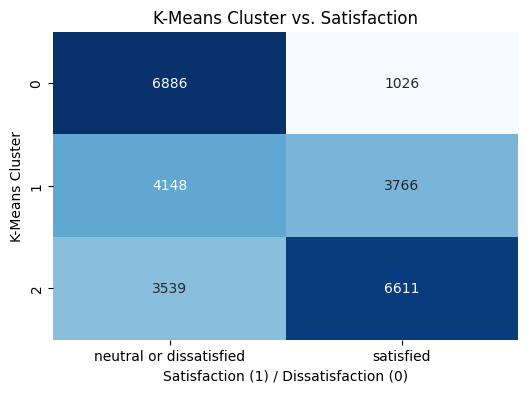

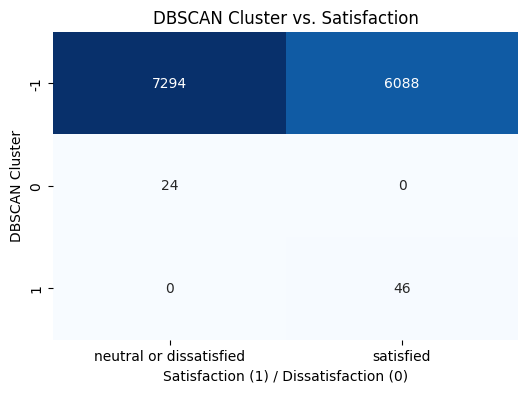

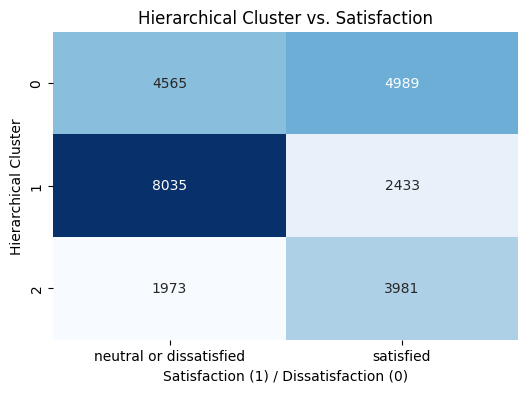

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from pandas import crosstab

# Assuming 'satisfaction' is the target variable in your dataset
# If it doesn't exist, create a synthetic target variable for demonstration
if 'satisfaction' not in data.columns:
    data['satisfaction'] = np.random.randint(0, 2, size=len(data))  # Random binary target (0 or 1)

# K-Means Contingency Table
kmeans_ct = crosstab(data['KMeans_Cluster'], data['satisfaction'])
print("K-Means Contingency Table:\n", kmeans_ct)

# Filter DBSCAN clusters to include only -1, 0, and 1
filtered_data = data[data['DBSCAN_Cluster'].isin([-1, 0, 1])]

# DBSCAN Contingency Table
dbscan_ct = crosstab(filtered_data['DBSCAN_Cluster'], filtered_data['satisfaction'])
print("DBSCAN Contingency Table:\n", dbscan_ct)



# Hierarchical Clustering Contingency Table
hierarchical_ct = crosstab(data['Hierarchical_Cluster'], data['satisfaction'])
print("Hierarchical Clustering Contingency Table:\n", hierarchical_ct)

# Function to plot heatmap
def plot_heatmap(ct, title, ylabel):
    plt.figure(figsize=(6, 4))
    sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Satisfaction (1) / Dissatisfaction (0)")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()

# Visualizations
plot_heatmap(kmeans_ct, "K-Means Cluster vs. Satisfaction", "K-Means Cluster")
plot_heatmap(dbscan_ct, "DBSCAN Cluster vs. Satisfaction", "DBSCAN Cluster")
plot_heatmap(hierarchical_ct, "Hierarchical Cluster vs. Satisfaction", "Hierarchical Cluster")